# Particle Swarm Optimization (PSO)

In [1]:
import os
import pandas as pd
import numpy as np
import pyswarms as ps
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Data
df = pd.read_csv('processed_cicids2017.csv')

# Drop missing values if any
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
feature_names = X.columns.tolist()

# Train/Test Split
# We use a stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")


Total Features: 77
Training Samples: 201663


In [3]:
class PSOSelector:
    def __init__(self, X_train, y_train, n_particles=15, n_iterations=10, penalty_factor=0.05, n_jobs=4):
        self.X_train = X_train
        self.y_train = y_train
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.penalty = penalty_factor
        self.n_jobs = n_jobs
        
        # optimization: Use a validation fold for speed
        self.X_sub, self.X_val, self.y_sub, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )
        
        self.pbar = None
        self.history = {'iteration': [], 'accuracy': [], 'features': [], 'cost': []}
        self.training_time = 0

    def f_per_particle(self, m):
        """
        Computes the fitness/cost for a single particle.
        Cost = (1 - Accuracy) + (Penalty * N_Features / Total_Features)
        """
        total_features = self.X_sub.shape[1]
        
        # Get selected feature indices (where position > 0.5)
        selected_indices = np.where(m > 0.5)[0]
        
        # Calculate selected feature count
        n_selected = len(selected_indices)
        
        # If no features selected, return high cost
        if n_selected == 0:
            return 1.0
        
        # Subset data
        X_sub_sel = self.X_sub[:, selected_indices]
        X_val_sel = self.X_val[:, selected_indices]
        
        # Train and Validate
        # FIX: Instantiate local classifier to ensure thread safety
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_sub_sel, self.y_sub)
        y_pred = clf.predict(X_val_sel)
        accuracy = accuracy_score(self.y_val, y_pred)
        
        # Cost Function
        error_rate = 1 - accuracy
        
        # Penalty term: penalize using more features
        # We normalize the feature count by total features to keep values comparable
        feature_penalty = (n_selected / total_features)
        
        # Final Cost
        cost = error_rate + (self.penalty * feature_penalty)
        return cost

    def f(self, x):
        """
        Objective function for the whole swarm.
        x: (n_particles, n_dimensions)
        """
        n_particles = x.shape[0]
        
        # Parallel Execution using Joblib (Threading backend)
        # This allows us to utilize CPU cores without Windows Multiprocessing Pickling issues
        j = Parallel(n_jobs=self.n_jobs, backend="threading")(
            delayed(self.f_per_particle)(x[i]) for i in range(n_particles)
        )
        
        costs = np.array(j)
        
        # --- History Tracking for Pareto ---
        # Find best in this batch (iteration)
        min_idx = np.argmin(costs)
        best_cost = costs[min_idx]
        best_particle = x[min_idx]
        
        # Recalculate components for the best particle to store pure Accuracy vs Features
        selected_indices = np.where(best_particle > 0.5)[0]
        n_selected = len(selected_indices)
        
        if n_selected > 0:
            X_sub_sel = self.X_sub[:, selected_indices]
            X_val_sel = self.X_val[:, selected_indices]
            clf = DecisionTreeClassifier(random_state=42)
            clf.fit(X_sub_sel, self.y_sub)
            acc = clf.score(X_val_sel, self.y_val)
        else:
            acc = 0.0
            
        self.history['accuracy'].append(acc)
        self.history['features'].append(n_selected)
        self.history['cost'].append(best_cost)
        self.history['iteration'].append(len(self.history['iteration']) + 1)
        
        # Update progress bar
        if self.pbar:
            self.pbar.update(1)
            self.pbar.set_description(f"PSO Best Cost: {best_cost:.4f} | Acc: {acc:.4f} | Feat: {n_selected}")

        return costs

    def run(self):
        # Initialize swarm
        options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
        dimensions = self.X_train.shape[1]
        
        optimizer = ps.single.GlobalBestPSO(n_particles=self.n_particles, dimensions=dimensions, options=options)
        
        # Initialize Progress Bar
        print(f"Starting PSO Optimization with {self.n_particles} particles, {self.n_iterations} iterations, {self.n_jobs} threads...")
        self.pbar = tqdm(total=self.n_iterations)
        
        start_time = time.time()
        
        # Perform optimization
        cost, pos = optimizer.optimize(self.f, self.n_iterations, verbose=False)
        
        end_time = time.time()
        self.training_time = end_time - start_time
        
        self.pbar.close()
        
        print(f"PSO execution complete. Time taken: {self.training_time:.2f} seconds.")
        
        return cost, pos, optimizer.cost_history

    def get_selected_features(self, pos, feature_names):
        selected_indices = np.where(pos > 0.5)[0]
        selected_names = [feature_names[i] for i in selected_indices]
        return selected_indices, selected_names, self.training_time

In [4]:
# Instantiate and Run PSO
# Use available CPU cores
n_jobs = os.cpu_count()
print(f"Using {n_jobs} CPU cores for processing.")

pso_selector = PSOSelector(X_train_scaled, y_train, n_particles=20, n_iterations=15, penalty_factor=0.05, n_jobs=n_jobs)

best_cost, best_pos, cost_history = pso_selector.run()

Using 12 CPU cores for processing.
Starting PSO Optimization with 20 particles, 15 iterations, 12 threads...


  0%|          | 0/15 [00:00<?, ?it/s]

PSO execution complete. Time taken: 170.38 seconds.


Final Minimum Cost: 0.0072
Number of Selected Features: 7
Computational Cost (Runtime): 170.3849 seconds
Selected Features: ['Bwd Packet Length Mean', 'Flow IAT Mean', 'Packet Length Mean', 'ACK Flag Count', 'Subflow Fwd Packets', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']


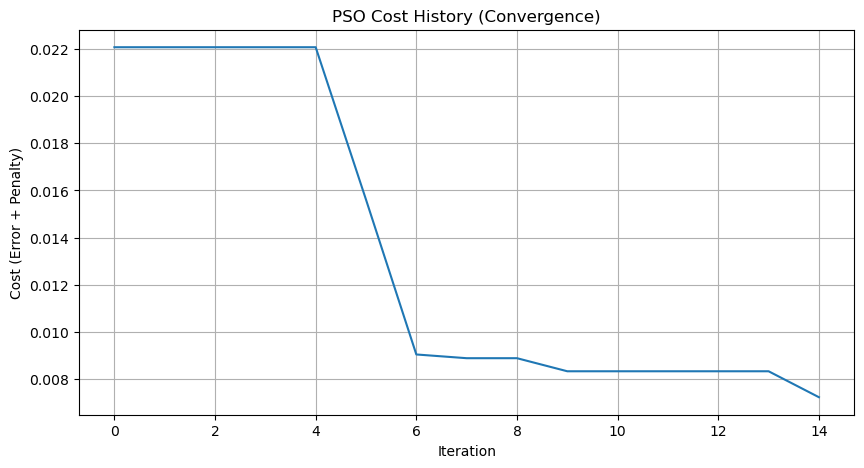

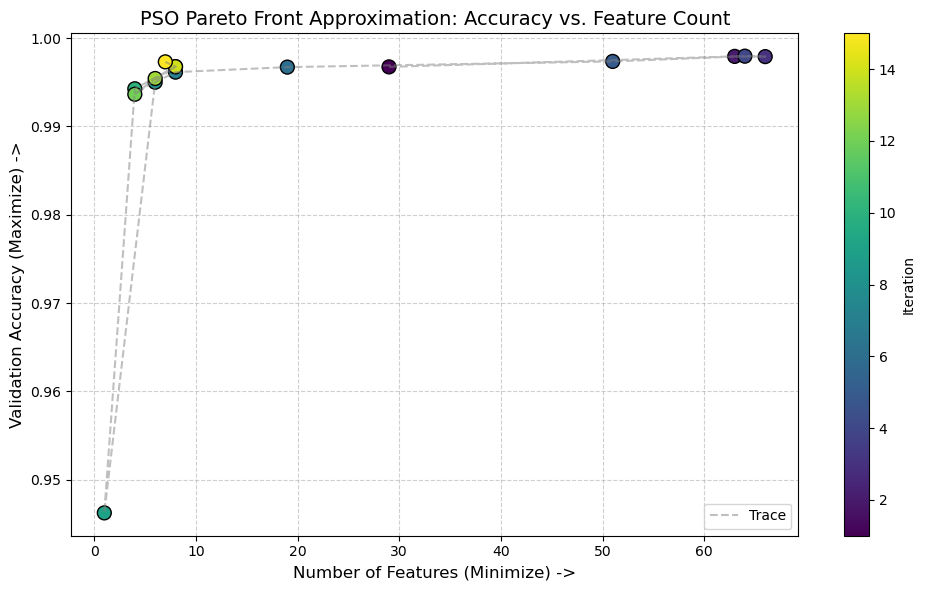

In [5]:
# Analyze Results

# Get feature names
selected_indices, selected_features, pso_runtime = pso_selector.get_selected_features(best_pos, feature_names)

print(f"Final Minimum Cost: {best_cost:.4f}")
print(f"Number of Selected Features: {len(selected_features)}")
print(f"Computational Cost (Runtime): {pso_runtime:.4f} seconds")
print(f"Selected Features: {selected_features}")

# Plot Cost History
plt.figure(figsize=(10, 5))
plt.plot(cost_history)
plt.title('PSO Cost History (Convergence)')
plt.xlabel('Iteration')
plt.ylabel('Cost (Error + Penalty)')
plt.grid(True)
plt.show()

# --- Pareto Front Visualization ---
# Using the history tracked during optimization
history = pso_selector.history

plt.figure(figsize=(10, 6))
# Evolution Path
plt.plot(history['features'], history['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Trace')
# Points (Iterations)
plt.scatter(history['features'], history['accuracy'], c=history['iteration'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Iteration')
plt.title('PSO Pareto Front Approximation: Accuracy vs. Feature Count', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Training Classifier with Selected Features...

Classification Report (PSO Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      0.99      0.99      8515

    accuracy                           1.00     50416
   macro avg       0.99      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== PSO Final Metrics ===
Accuracy: 0.997223
Precision: 0.997225
Recall: 0.997223
F1-Score: 0.997224
Detection Rate (TPR): 0.992366
False Positive Rate (FPR): 0.001790
Feature Count: 7.000000
Runtime (s): 170.384860


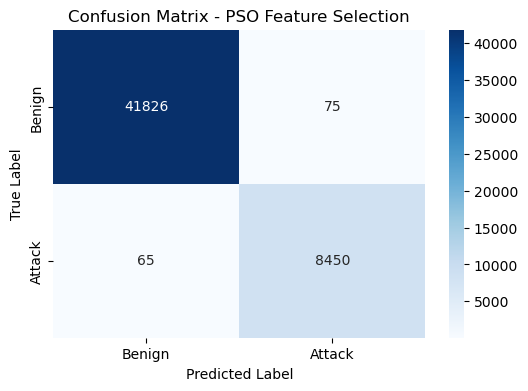

In [6]:
# Train Final Model with PSO Selected Features

print("Training Classifier with Selected Features...")
X_train_pso = X_train_scaled[:, selected_indices]
X_test_pso = X_test_scaled[:, selected_indices]

final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train_pso, y_train)

y_pred_pso = final_model.predict(X_test_pso)

# Evaluate
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_pso).ravel()

acc_pso = accuracy_score(y_test, y_pred_pso)
prec_pso = precision_score(y_test, y_pred_pso, average='weighted')
rec_pso = recall_score(y_test, y_pred_pso, average='weighted')
f1_pso = f1_score(y_test, y_pred_pso, average='weighted')

detection_rate_pso = tp / (tp + fn)
false_positive_rate_pso = fp / (fp + tn)

print("\nClassification Report (PSO Selected Features):")
print(classification_report(y_test, y_pred_pso))

pso_final_metrics = {
    'Accuracy': acc_pso,
    'Precision': prec_pso,
    'Recall': rec_pso,
    'F1-Score': f1_pso,
    'Detection Rate (TPR)': detection_rate_pso,
    'False Positive Rate (FPR)': false_positive_rate_pso,
    'Feature Count': len(selected_features),
    'Runtime (s)': pso_runtime
}

print("=== PSO Final Metrics ===")
for k, v in pso_final_metrics.items():
    print(f"{k}: {v:.6f}")

# Confusion Matrix
conf_matrix_pso = confusion_matrix(y_test, y_pred_pso)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_pso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - PSO Feature Selection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

PSO metrics saved to results/pso_metrics.json

=== Model Comparison Results ===
                Baseline  PSO Selection
Accuracy        0.998155       0.997223
Precision       0.998156       0.997225
Recall          0.998155       0.997223
F1-Score        0.998155       0.997224
Feature Count  77.000000       7.000000


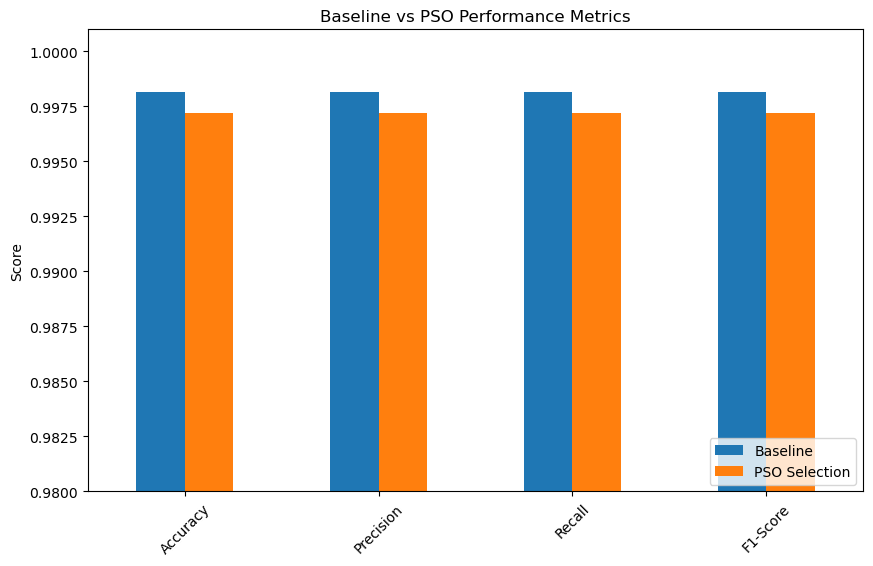


Feature Reduction: 77 -> 7 (90.91% reduction)


In [7]:
# --- COMPARISON WITH BASELINE ---

# 1. Load Baseline Metrics from JSON
try:
    with open('results/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except FileNotFoundError:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Feature Count': 77
    }

# 2. Define PSO Metrics for Comparison
pso_metrics = {
    'Method': 'Particle Swarm Optimization (PSO)',
    'Accuracy': acc_pso,
    'Precision': prec_pso,
    'Recall': rec_pso,
    'F1-Score': f1_pso,
    'Detection Rate (TPR)': detection_rate_pso,
    'False Positive Rate (FPR)': false_positive_rate_pso,
    'Feature Count': len(selected_features),
    'Runtime (s)': pso_runtime
}

# --- SAVE PSO METRICS to JSON ---
pso_metrics_path = 'results/pso_metrics.json'
with open(pso_metrics_path, 'w') as f:
    json.dump(pso_metrics, f, indent=4)
print(f"PSO metrics saved to {pso_metrics_path}")

# 3. Create Comparison Table
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count']
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
pso_filtered = {k: pso_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, pso_filtered], index=['Baseline', 'PSO Selection'])
print("\n=== Model Comparison Results ===")
print(results_df.T)

# 4. Visualization
results_without_count = results_df.drop('Feature Count', axis=1)
results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs PSO Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.98, 1.001) 
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

# Print Reduction
reduction = ((baseline_metrics['Feature Count'] - pso_metrics['Feature Count']) / baseline_metrics['Feature Count']) * 100
print(f"\nFeature Reduction: {baseline_metrics['Feature Count']} -> {pso_metrics['Feature Count']} ({reduction:.2f}% reduction)")